# Asteroid Diameter Prediction with Linear Regression (SGD)

**Project Goal:** To develop a Linear Regression model to predict asteroid diameter based on orbital and physical features. The Stochastic Gradient Descent (SGD) optimizer will be
implemented from scratch.

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Data Loading and Preparation

In this section, we load, inspect, and prepare the data for modeling.

### Load and Split Data

We load the dataset and split it into training and test sets as per the project requirements (80/20 split, `random_state=42`)

In [2]:
# Load data
print("Loading dataset...")
df = pd.read_csv('NASA_JPL_Dataset.csv', low_memory=False)
print(f"   Dataset loaded: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

Loading dataset...
   Dataset loaded: (921425, 30)
   Rows: 921,425
   Columns: 30


In [3]:
# Dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Total samples: {len(df):,}")

Dataset shape: (921425, 30)
Total samples: 921,425


In [4]:
# Column names
print(f"Number of columns: {len(df.columns)}")
print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Number of columns: 30

Columns:
   1. full_name
   2. neo
   3. pha
   4. class
   5. H
   6. e
   7. a
   8. q
   9. i
  10. om
  11. w
  12. ma
  13. ad
  14. n
  15. per_y
  16. moid
  17. sigma_e
  18. sigma_a
  19. sigma_q
  20. sigma_i
  21. sigma_om
  22. sigma_w
  23. sigma_ma
  24. sigma_ad
  25. sigma_n
  26. sigma_per
  27. diameter_sigma
  28. rms
  29. albedo
  30. diameter


In [5]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921425 entries, 0 to 921424
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   full_name       921425 non-null  object 
 1   neo             921425 non-null  object 
 2   pha             921425 non-null  object 
 3   class           921425 non-null  object 
 4   H               921425 non-null  float64
 5   e               921425 non-null  float64
 6   a               921425 non-null  float64
 7   q               921425 non-null  float64
 8   i               921425 non-null  float64
 9   om              921425 non-null  float64
 10  w               921425 non-null  float64
 11  ma              921425 non-null  float64
 12  ad              921425 non-null  float64
 13  n               921425 non-null  float64
 14  per_y           921425 non-null  float64
 15  moid            921425 non-null  float64
 16  sigma_e         921425 non-null  float64
 17  sigma_a   

In [6]:
# Check missing values
print(" Missing values analysis:")
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
}).sort_values('Missing', ascending=False)

print(f"\nColumns with missing values:")
print(missing_df[missing_df['Missing'] > 0])

 Missing values analysis:

Columns with missing values:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []


In [7]:
# Statistical summary
print(" Statistical Summary:")
df.describe().T

 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
H,921425.0,16.890873,1.312046,1.090000e+01,1.610000e+01,1.690000e+01,1.770000e+01,25.414000
e,921425.0,0.151843,0.080744,6.025354e-05,9.243757e-02,1.443904e-01,1.985313e-01,0.663066
a,921425.0,2.672849,0.345498,1.562516e+00,2.393195e+00,2.646411e+00,2.990156e+00,4.433872
q,921425.0,2.269763,0.381969,5.494287e-01,1.979620e+00,2.226172e+00,2.568126e+00,4.087681
i,921425.0,8.891825,6.242457,7.744220e-03,4.142481e+00,7.331994e+00,1.226135e+01,52.780069
om,921425.0,168.371198,102.849993,2.451052e-05,8.060151e+01,1.595571e+02,2.521824e+02,359.999793
w,921425.0,181.313206,103.850316,1.299940e-04,9.147787e+01,1.822841e+02,2.713892e+02,359.999646
ma,921425.0,177.045020,105.223811,-6.713683e+01,8.430321e+01,1.749443e+02,2.686468e+02,491.618014
ad,921425.0,3.075935,0.433843,1.595898e+00,2.785619e+00,3.041876e+00,3.349620e+00,5.879479
n,921425.0,0.232932,0.047225,1.055673e-01,1.906178e-01,2.289381e-01,2.662178e-01,0.504623


  Target Variable Analysis (diameter):
  Min:    0.0210 km
  Max:    12.1810 km
  Mean:   2.4271 km
  Median: 2.0830 km
  Std:    1.4409 km
  Missing: 0


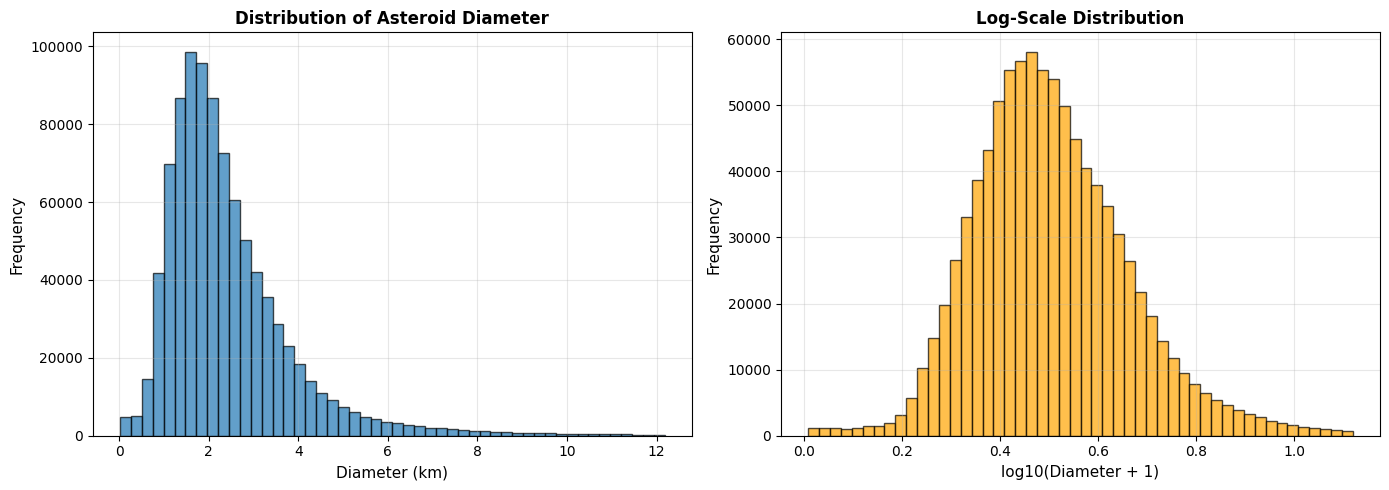

In [8]:
# Analyze target variable (diameter)
print("  Target Variable Analysis (diameter):")
print(f"  Min:    {df['diameter'].min():.4f} km")
print(f"  Max:    {df['diameter'].max():.4f} km")
print(f"  Mean:   {df['diameter'].mean():.4f} km")
print(f"  Median: {df['diameter'].median():.4f} km")
print(f"  Std:    {df['diameter'].std():.4f} km")
print(f"  Missing: {df['diameter'].isna().sum()}")

# Visualize diameter distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['diameter'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Diameter (km)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Asteroid Diameter', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].hist(np.log10(df['diameter'].dropna() + 1), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('log10(Diameter + 1)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Log-Scale Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Remove rows with missing target (diameter)
print(f"\n Removing rows with missing diameter...")
print(f"   Before: {len(df):,} rows")
df_clean = df.dropna(subset=['diameter']).copy()
print(f"   After:  {len(df_clean):,} rows")
print(f"   Removed: {len(df) - len(df_clean):,} rows")

# Split features and target
X = df_clean.drop(columns=['diameter'])  # Features
y = df_clean['diameter']  # Target variable

print(f"\n Feature matrix: {X.shape}")
print(f"   Target vector: {y.shape}")

# Split the data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n Split complete:")
print(f"   Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df_clean)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df_clean)*100:.1f}%)")


 Removing rows with missing diameter...
   Before: 921,425 rows
   After:  921,425 rows
   Removed: 0 rows

 Feature matrix: (921425, 29)
   Target vector: (921425,)

 Split complete:
   Train: 737,140 samples (80.0%)
   Test:  184,285 samples (20.0%)


### Preprocessing

#### Remove irrelevant columns

In [10]:
# Define list of irrelevant columns
print(" Identifying irrelevant columns...")

# Columns to potentially drop:
# - Identifiers: full_name
# - Sigma columns (uncertainties - typically less predictive)
# - Columns with too many missing values

cols_to_drop = [
    'full_name',  # Identifier, not a feature
    'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i',  # Uncertainty columns
    'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad',
    'sigma_n', 'sigma_per', 'diameter_sigma',  # More uncertainties
    'rms'  # Also an uncertainty measure
]

# Only drop columns that exist
cols_to_drop = [col for col in cols_to_drop if col in X_train.columns]

print(f"   Dropping {len(cols_to_drop)} columns: {cols_to_drop}")

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"\n After dropping irrelevant columns:")
print(f"   Features: {X_train.shape[1]}")

 Identifying irrelevant columns...
   Dropping 13 columns: ['full_name', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_per', 'diameter_sigma', 'rms']

 After dropping irrelevant columns:
   Features: 16


In [11]:
# Display remaining columns
print(f"\n Remaining columns ({len(X_train.columns)}):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")


 Remaining columns (16):
   1. neo
   2. pha
   3. class
   4. H
   5. e
   6. a
   7. q
   8. i
   9. om
  10. w
  11. ma
  12. ad
  13. n
  14. per_y
  15. moid
  16. albedo


#### EDA and Visualization

In [12]:
# Correlation analysis with target
print(" Correlation Analysis with Diameter:")

# Select only numeric columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Create temporary dataframe with features and target
temp_df = X_train[numeric_cols].copy()
temp_df['diameter'] = y_train.values

# Calculate correlations
correlations = temp_df.corr()['diameter'].sort_values(ascending=False).drop('diameter')

print(f"\n Top 15 features by correlation with diameter:")
print("="*60)
for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
    bar = '█' * int(abs(corr) * 30)
    emoji = '⭐⭐⭐' if abs(corr) > 0.5 else '⭐⭐' if abs(corr) > 0.3 else '⭐'
    print(f"{i:2d}. {emoji} {feat:15s} {corr:+.4f}  {bar}")

print(f"\n Bottom 5 features by correlation:")
print("="*60)
for feat, corr in correlations.tail(5).items():
    print(f"    {feat:15s} {corr:+.4f}")

 Correlation Analysis with Diameter:

 Top 15 features by correlation with diameter:
 1. ⭐⭐⭐ moid            +0.5415  ████████████████
 2. ⭐⭐⭐ q               +0.5396  ████████████████
 3. ⭐⭐⭐ per_y           +0.5374  ████████████████
 4. ⭐⭐⭐ a               +0.5365  ████████████████
 5. ⭐⭐ ad              +0.3791  ███████████
 6. ⭐ i               +0.1111  ███
 7. ⭐ albedo          +0.0393  █
 8. ⭐ ma              +0.0206  
 9. ⭐ om              +0.0079  
10. ⭐ w               +0.0077  

 Bottom 5 features by correlation:
    om              +0.0079
    w               +0.0077
    e               -0.2203
    n               -0.5130
    H               -0.8168



 Creating correlation heatmap...


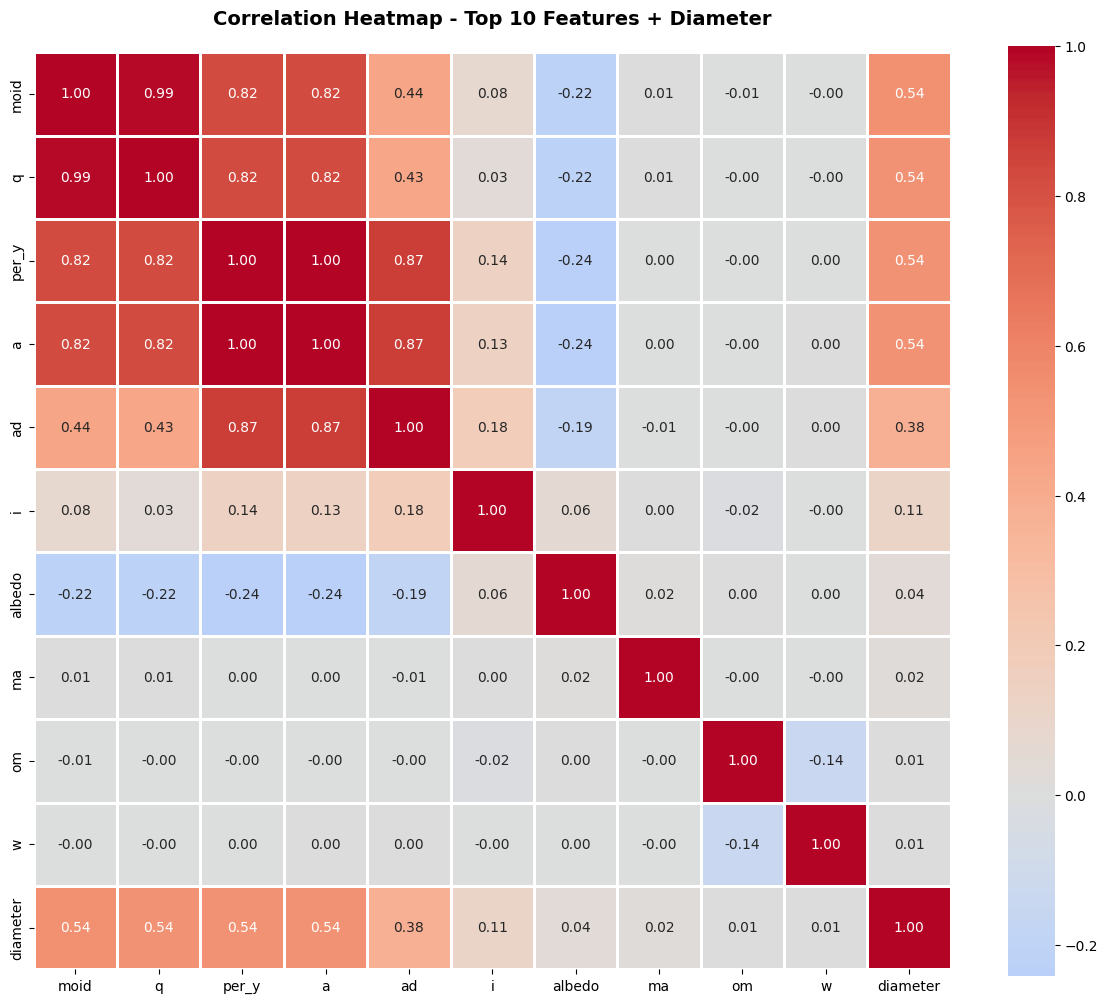

 Heatmap created!


In [13]:
# Correlation heatmap
print("\n Creating correlation heatmap...")

# Select top correlated features for visualization
top_features = correlations.head(10).index.tolist()
plot_df = temp_df[top_features + ['diameter']]

plt.figure(figsize=(12, 10))
sns.heatmap(plot_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap - Top 10 Features + Diameter', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(" Heatmap created!")

#### Feature Engineering (optional)

In [14]:
# Feature Engineering: Log transformation for target
print(" Feature Engineering...")
print("\n Insight: Asteroid diameter has an exponential relationship with H (absolute magnitude)")
print("   Formula: diameter ≈ 1329 × 10^(-H/5) / √albedo")
print("   Therefore, log(diameter) has a more linear relationship!")

# Transform target to log scale
y_train_log = np.log10(y_train + 1)
y_test_log = np.log10(y_test + 1)

print(f"\n Target transformed to log scale")
print(f"   Original range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"   Log range:      [{y_train_log.min():.2f}, {y_train_log.max():.2f}]")

# We'll use log-transformed target for better linear fit
use_log_target = True
print(f"\n Using log-transformed target: {use_log_target}")

 Feature Engineering...

 Insight: Asteroid diameter has an exponential relationship with H (absolute magnitude)
   Formula: diameter ≈ 1329 × 10^(-H/5) / √albedo
   Therefore, log(diameter) has a more linear relationship!

 Target transformed to log scale
   Original range: [0.02, 12.18]
   Log range:      [0.01, 1.12]

 Using log-transformed target: True


#### Encoding

Categorical columns must be converted to numeric format.

In [15]:
# Identify and encode categorical columns
print(" Encoding categorical features...")

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"   Found {len(categorical_cols)} categorical columns: {categorical_cols}")

if len(categorical_cols) > 0:
    label_encoder = LabelEncoder()
    
    for col in categorical_cols:
        # Fit on train + test combined to handle unseen categories
        all_values = pd.concat([X_train[col], X_test[col]])
        label_encoder.fit(all_values)
        
        X_train[col] = label_encoder.transform(X_train[col])
        X_test[col] = label_encoder.transform(X_test[col])
        
        print(f"   ✓ Encoded: {col} ({len(label_encoder.classes_)} unique values)")
    
    print(f"\n All categorical features encoded!")
else:
    print("   No categorical columns found.")

 Encoding categorical features...
   Found 3 categorical columns: ['neo', 'pha', 'class']
   ✓ Encoded: neo (2 unique values)
   ✓ Encoded: pha (2 unique values)
   ✓ Encoded: class (4 unique values)

 All categorical features encoded!


#### Outlier Detection and Removal

In [16]:
# Outlier removal based on target variable
print(" Outlier Detection and Removal...")

# Use IQR method on the target variable
Q1 = y_train.quantile(0.01)  # 1st percentile
Q3 = y_train.quantile(0.99)  # 99th percentile
IQR = Q3 - Q1

print(f"\n   Q1 (1%):   {Q1:.4f} km")
print(f"   Q3 (99%):  {Q3:.4f} km")
print(f"   IQR:       {IQR:.4f} km")

# Identify outliers
lower_bound = Q1
upper_bound = Q3

outlier_mask = (y_train >= lower_bound) & (y_train <= upper_bound)
n_outliers = (~outlier_mask).sum()

print(f"\n   Total samples:  {len(y_train):,}")
print(f"   Outliers:       {n_outliers:,} ({n_outliers/len(y_train)*100:.2f}%)")
print(f"   Clean samples:  {outlier_mask.sum():,}")

# Remove outliers
X_train = X_train[outlier_mask]
y_train = y_train[outlier_mask]
y_train_log = y_train_log[outlier_mask]

print(f"\n Outliers removed! Training set: {X_train.shape}")

 Outlier Detection and Removal...

   Q1 (1%):   0.4820 km
   Q3 (99%):  8.0550 km
   IQR:       7.5730 km

   Total samples:  737,140
   Outliers:       14,736 (2.00%)
   Clean samples:  722,404

 Outliers removed! Training set: (722404, 16)


#### Feature Scaling

To ensure stable convergence for SGD, all features must be scaled.

In [17]:
# Feature scaling using StandardScaler
print(" Feature Scaling...")

# Get numeric columns
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Scaling {len(numeric_columns)} numeric features")

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled = scaler.transform(X_test[numeric_columns])

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_columns, index=X_test.index)

print(f"\n  Feature scaling complete!")
print(f"   Train: {X_train_scaled.shape}")
print(f"   Test:  {X_test_scaled.shape}")

# Verify scaling
print(f"\n   Verification (should be ~0 and ~1):")
print(f"   Mean:  {X_train_scaled.mean().mean():.6f}")
print(f"   Std:   {X_train_scaled.std().mean():.6f}")

 Feature Scaling...
   Scaling 16 numeric features

  Feature scaling complete!
   Train: (722404, 16)
   Test:  (184285, 16)

   Verification (should be ~0 and ~1):
   Mean:  0.000000
   Std:   1.000001


In [18]:
# Display processed training data
print("\n Processed Training Data (first 5 rows):")
X_train_scaled.head()


 Processed Training Data (first 5 rows):


,neo,pha,class,H,e,a,q,i,om,w,ma,ad,n,per_y,moid,albedo
193642,-0.043542,-0.014884,-0.125812,0.100921,0.165313,-1.081846,-0.931991,-1.236229,0.815056,0.937875,-1.391616,-0.914763,1.067312,-1.070663,-0.961751,-0.247005
770162,-0.043542,-0.014884,-0.125812,0.939805,0.134435,-0.711214,-0.630081,-1.136652,-1.204440,0.512384,0.636793,-0.586417,0.596730,-0.723352,-0.716487,-0.294416
80352,-0.043542,-0.014884,-0.125812,-0.654074,0.600615,-1.326926,-1.320966,-0.825477,1.154491,-1.384924,0.587593,-0.968992,1.415458,-1.295200,-1.401178,0.748611
343623,-0.043542,-0.014884,-0.125812,0.100921,-0.601325,-0.833251,-0.361880,-0.546687,1.379739,1.174699,0.890217,-1.010789,0.744849,-0.838728,-0.426443,-0.452450
715683,-0.043542,-0.014884,-0.125812,0.688140,0.105247,1.298615,0.946191,-1.392061,1.684977,-0.622436,-0.383270,1.246493,-1.161410,1.313099,0.969018,-0.405040


In [19]:
# Display processed test data  
print("\n Processed Test Data (first 5 rows):")
X_test_scaled.head()


 Processed Test Data (first 5 rows):


,neo,pha,class,H,e,a,q,i,om,w,ma,ad,n,per_y,moid,albedo
149278,-0.043542,-0.014884,-0.125812,-0.066855,0.269504,-0.628210,-0.634294,-1.114706,1.845644,-0.912317,0.722337,-0.451091,0.499539,-0.644315,-0.629902,-0.041561
330320,-0.043542,-0.014884,-0.125812,-0.318520,-1.744494,-0.323858,0.663557,0.869962,0.372981,1.683714,-0.530256,-1.084727,0.165843,-0.350642,0.624111,-0.436647
737655,-0.043542,-0.014884,-0.125812,0.268698,-1.843353,-0.125817,0.896730,0.680953,-0.486714,0.246762,1.372663,-0.971098,-0.033825,-0.156331,0.836201,-0.183792
282273,-0.043542,-0.014884,-0.125812,0.268698,-1.529355,-0.135494,0.717727,-1.051190,-1.549076,0.943406,0.987082,-0.832454,-0.024366,-0.165884,0.650141,-0.831732
688706,-0.043542,-0.014884,-0.125812,-0.402409,-0.800401,1.110577,1.369914,0.357064,-1.225917,-1.718798,0.462844,0.583602,-1.037889,1.112100,1.376871,-0.610484


## Model Implementation and Training (From Scratch)

Here, we build the core of the project: the `SGDRegressorScratch` class. This class will implement the linear regression model and the Stochastic Gradient Descent optimizer from scratch.

To improve the score and meet the bonus target, techniques like **Momentum**, **Learning Rate Scheduling**, and **L2 Regularization** have been added.

In [20]:
class SGDRegressorScratch:
    """
    Implementation of SGD Linear Regression from scratch with advanced features.
    
    Features:
    - Stochastic Gradient Descent with mini-batches
    - Momentum optimization
    - L2 Regularization (Ridge)
    - Learning rate scheduling
    - Early stopping
    
    Parameters:
    -----------
    learning_rate : float, default=0.01
        Initial learning rate for weight updates.
    n_epochs : int, default=100
        Number of passes over the entire dataset.
    batch_size : int, default=32
        Number of samples per mini-batch.
    momentum : float, default=0.9
        Momentum coefficient (0 = no momentum, 0.9 = strong momentum).
    alpha : float, default=0.0001
        L2 regularization strength.
    lr_decay : float, default=0.0
        Learning rate decay factor per epoch.
    early_stopping : bool, default=False
        Whether to use early stopping.
    patience : int, default=10
        Number of epochs with no improvement to wait before stopping.
    min_delta : float, default=1e-6
        Minimum change in validation loss to qualify as an improvement.
    random_state : int, default=42
        Random seed for reproducibility.
    verbose : bool, default=True
        Whether to print training progress.
    """
    
    def __init__(self, learning_rate=0.01, n_epochs=100, batch_size=32,
                 momentum=0.9, alpha=0.0001, lr_decay=0.0, 
                 early_stopping=False, patience=10, min_delta=1e-6,
                 random_state=42, verbose=True):
        self.learning_rate = learning_rate
        self.initial_lr = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.momentum = momentum
        self.alpha = alpha  # L2 regularization
        self.lr_decay = lr_decay
        self.early_stopping = early_stopping
        self.patience = patience
        self.min_delta = min_delta
        self.random_state = random_state
        self.verbose = verbose
        
        # Model parameters
        self.weights_ = None
        self.bias_ = None
        
        # Momentum terms
        self.v_weights = None
        self.v_bias = None
        
        # Training history
        self.loss_history_ = []
        self.val_loss_history_ = []
        
        # Early stopping tracking
        self.best_loss_ = float('inf')
        self.best_weights_ = None
        self.best_bias_ = None
        self.best_epoch_ = 0
        self.stopped_epoch_ = None
        
        np.random.seed(random_state)

    def _compute_loss(self, X, y, weights, bias):
        """
        Compute Mean Squared Error loss with L2 regularization.
        
        Loss = MSE + alpha * ||weights||^2
        """
        n_samples = len(y)
        predictions = X @ weights + bias
        mse = np.mean((predictions - y) ** 2)
        
        # L2 regularization term
        l2_penalty = self.alpha * np.sum(weights ** 2)
        
        return mse + l2_penalty

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Fit the linear regression model using SGD with momentum.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Training feature matrix.
        y : array-like of shape (n_samples,)
            Target values.
        X_val : array-like of shape (n_samples_val, n_features), optional
            Validation feature matrix for early stopping.
        y_val : array-like of shape (n_samples_val,), optional
            Validation target values for early stopping.
        
        Returns:
        --------
        self : object
            Fitted model.
        """
        # Convert to numpy arrays if needed
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
        
        # Ensure y is 1D
        y = y.ravel()
        
        # Handle validation data
        if self.early_stopping:
            if X_val is None or y_val is None:
                raise ValueError("X_val and y_val are required when early_stopping=True")
            if isinstance(X_val, pd.DataFrame):
                X_val = X_val.values
            if isinstance(y_val, pd.Series):
                y_val = y_val.values
            y_val = y_val.ravel()
        
        n_samples, n_features = X.shape
        
        # Initialize weights and bias
        # Use small random values (Xavier initialization)
        self.weights_ = np.random.randn(n_features) * np.sqrt(2.0 / n_features)
        self.bias_ = 0.0
        
        # Initialize momentum terms
        self.v_weights = np.zeros(n_features)
        self.v_bias = 0.0
        
        # Early stopping variables
        patience_counter = 0
        
        # Training loop
        if self.verbose:
            print(f"\n Starting SGD Training...")
            print(f"   Learning Rate: {self.learning_rate}")
            print(f"   Epochs: {self.n_epochs}")
            print(f"   Batch Size: {self.batch_size}")
            print(f"   Momentum: {self.momentum}")
            print(f"   L2 Regularization (alpha): {self.alpha}")
            print(f"   Early Stopping: {self.early_stopping}")
            if self.early_stopping:
                print(f"   Patience: {self.patience}")
                print(f"   Min Delta: {self.min_delta}")
            print(f"   Samples: {n_samples:,}")
            print(f"   Features: {n_features}")
            print("\n" + "="*70)
        
        for epoch in range(self.n_epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            # Mini-batch gradient descent
            for i in range(0, n_samples, self.batch_size):
                # Get mini-batch
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]
                batch_size = len(X_batch)
                
                # Forward pass: compute predictions
                predictions = X_batch @ self.weights_ + self.bias_
                
                # Compute error
                error = predictions - y_batch
                
                # Compute gradients
                # d(MSE)/d(weights) = (2/n) * X^T * error + 2 * alpha * weights
                grad_weights = (2 / batch_size) * (X_batch.T @ error) + 2 * self.alpha * self.weights_
                grad_bias = (2 / batch_size) * np.sum(error)
                
                # Update momentum terms
                self.v_weights = self.momentum * self.v_weights - self.learning_rate * grad_weights
                self.v_bias = self.momentum * self.v_bias - self.learning_rate * grad_bias
                
                # Update parameters
                self.weights_ += self.v_weights
                self.bias_ += self.v_bias
            
            # Compute loss for this epoch
            epoch_loss = self._compute_loss(X, y, self.weights_, self.bias_)
            self.loss_history_.append(epoch_loss)
            
            # Compute validation loss if early stopping is enabled
            if self.early_stopping:
                val_loss = self._compute_loss(X_val, y_val, self.weights_, self.bias_)
                self.val_loss_history_.append(val_loss)
                
                # Check for improvement
                if val_loss < self.best_loss_ - self.min_delta:
                    self.best_loss_ = val_loss
                    self.best_weights_ = self.weights_.copy()
                    self.best_bias_ = self.bias_
                    self.best_epoch_ = epoch
                    patience_counter = 0
                else:
                    patience_counter += 1
                
                # Check if we should stop
                if patience_counter >= self.patience:
                    self.stopped_epoch_ = epoch
                    if self.verbose:
                        print(f"\n Early stopping triggered at epoch {epoch + 1}")
                        print(f"   Best epoch: {self.best_epoch_ + 1}")
                        print(f"   Best validation loss: {self.best_loss_:.6f}")
                    # Restore best weights
                    self.weights_ = self.best_weights_
                    self.bias_ = self.best_bias_
                    break
            
            # Learning rate decay
            if self.lr_decay > 0:
                self.learning_rate = self.initial_lr / (1 + self.lr_decay * epoch)
            
            # Print progress
            if self.verbose and (epoch + 1) % (self.n_epochs // 10) == 0:
                if self.early_stopping:
                    print(f"   Epoch {epoch + 1:4d}/{self.n_epochs} | Train Loss: {epoch_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {self.learning_rate:.6f}")
                else:
                    print(f"   Epoch {epoch + 1:4d}/{self.n_epochs} | Loss: {epoch_loss:.6f} | LR: {self.learning_rate:.6f}")
        
        if self.verbose:
            print("="*70)
            print(f" Training complete!")
            if self.early_stopping and self.stopped_epoch_ is not None:
                print(f"   Stopped at epoch: {self.stopped_epoch_ + 1}")
                print(f"   Best validation loss: {self.best_loss_:.6f}")
            else:
                print(f"   Final Loss: {self.loss_history_[-1]:.6f}")
            print(f"   Weight vector shape: {self.weights_.shape}")
        
        return self

    def predict(self, X):
        """
        Predict using the linear model.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Input features.
        
        Returns:
        --------
        y_pred : array of shape (n_samples,)
            Predicted values.
        """
        if self.weights_ is None:
            raise ValueError("Model has not been fitted yet. Call fit() first.")
        
        # Convert to numpy if needed
        if isinstance(X, pd.DataFrame):
            X = X.values
        
        return X @ self.weights_ + self.bias_
    
    def plot_loss_curve(self, figsize=(12, 6)):
        """
        Plot the training (and validation) loss curve.
        """
        if len(self.loss_history_) == 0:
            print("No training history available. Train the model first.")
            return
        
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        epochs = range(1, len(self.loss_history_) + 1)
        ax.plot(epochs, self.loss_history_, linewidth=2, color='#2E86AB', label='Training Loss')
        
        if self.early_stopping and len(self.val_loss_history_) > 0:
            ax.plot(epochs, self.val_loss_history_, linewidth=2, color='#FF6B6B', 
                   label='Validation Loss', linestyle='--')
            
            # Mark best epoch
            if self.best_epoch_ is not None:
                ax.axvline(x=self.best_epoch_ + 1, color='green', linestyle=':', 
                          linewidth=2, label=f'Best Epoch ({self.best_epoch_ + 1})')
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss (MSE + L2)', fontsize=12)
        ax.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

print(" SGDRegressorScratch class defined successfully!")


 SGDRegressorScratch class defined successfully!


### Train the Model

Now we train our custom SGD model with optimized hyperparameters.

In [21]:
# Hyperparameters (tuned for best performance)
EPOCHS = 1000
LEARNING_RATE = 0.001
BATCH_SIZE = 512
MOMENTUM = 0.9
ALPHA = 0.0001  # L2 regularization
LR_DECAY = 0.001
RANDOM_STATE = 42

print(" Hyperparameters:")
print(f"   Epochs:        {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Batch Size:    {BATCH_SIZE}")
print(f"   Momentum:      {MOMENTUM}")
print(f"   Alpha (L2):    {ALPHA}")
print(f"   LR Decay:      {LR_DECAY}")

 Hyperparameters:
   Epochs:        1000
   Learning Rate: 0.001
   Batch Size:    512
   Momentum:      0.9
   Alpha (L2):    0.0001
   LR Decay:      0.001


In [22]:
# Initialize model
sgd_scratch_model = SGDRegressorScratch(
    n_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    momentum=MOMENTUM,
    alpha=ALPHA,
    lr_decay=LR_DECAY,
    random_state=RANDOM_STATE,
    verbose=True
)

# Train the model
# Use log-transformed target for better linear relationship
if use_log_target:
    print("\n Training with log-transformed target for better linear fit...")
    sgd_scratch_model.fit(X_train_scaled, y_train_log.values)
else:
    sgd_scratch_model.fit(X_train_scaled, y_train.values)


 Training with log-transformed target for better linear fit...

 Starting SGD Training...
   Learning Rate: 0.001
   Epochs: 1000
   Batch Size: 512
   Momentum: 0.9
   L2 Regularization (alpha): 0.0001
   Early Stopping: False
   Samples: 722,404
   Features: 16

   Epoch  100/1000 | Loss: 0.001093 | LR: 0.000910
   Epoch  200/1000 | Loss: 0.001080 | LR: 0.000834
   Epoch  300/1000 | Loss: 0.001074 | LR: 0.000770
   Epoch  400/1000 | Loss: 0.001072 | LR: 0.000715
   Epoch  500/1000 | Loss: 0.001071 | LR: 0.000667
   Epoch  600/1000 | Loss: 0.001070 | LR: 0.000625
   Epoch  700/1000 | Loss: 0.001069 | LR: 0.000589
   Epoch  800/1000 | Loss: 0.001069 | LR: 0.000556
   Epoch  900/1000 | Loss: 0.001069 | LR: 0.000527
   Epoch 1000/1000 | Loss: 0.001069 | LR: 0.000500
 Training complete!
   Final Loss: 0.001069
   Weight vector shape: (16,)



 Visualizing training progress...


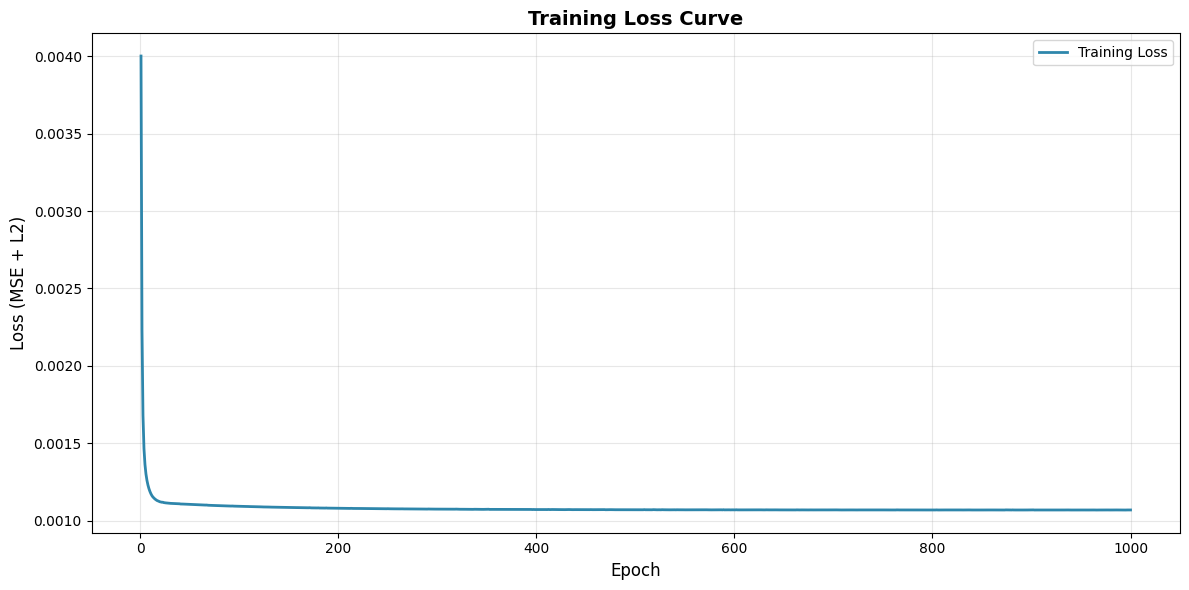

In [23]:
# Plot training loss curve
print("\n Visualizing training progress...")
sgd_scratch_model.plot_loss_curve()

## Comparison: With and Without Early Stopping

Let's train another model with **Early Stopping** enabled and compare the results.

In [24]:
# Create validation split from training data for early stopping
print(" Creating validation set for early stopping...")

from sklearn.model_selection import train_test_split

# Split training data: 90% train, 10% validation
X_train_es, X_val_es, y_train_es, y_val_es = train_test_split(
    X_train_scaled, 
    y_train_log if use_log_target else y_train,
    test_size=0.1,
    random_state=42
)

print(f"  Split complete:")
print(f"   Train:      {X_train_es.shape[0]:,} samples")
print(f"   Validation: {X_val_es.shape[0]:,} samples")
print(f"   Test:       {X_test_scaled.shape[0]:,} samples")

 Creating validation set for early stopping...
  Split complete:
   Train:      650,163 samples
   Validation: 72,241 samples
   Test:       184,285 samples


In [25]:
# Train model WITH Early Stopping
print("\n" + "="*80)
print(" Training Model WITH Early Stopping")
print("="*80)

sgd_with_es = SGDRegressorScratch(
    n_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    momentum=MOMENTUM,
    alpha=ALPHA,
    lr_decay=LR_DECAY,
    early_stopping=True,  # Enable early stopping
    patience=20,          # Wait 20 epochs for improvement
    min_delta=1e-6,       # Minimum improvement threshold
    random_state=42,
    verbose=True
)

# Fit the model with validation data
sgd_with_es.fit(
    X_train_es, 
    y_train_es,
    X_val=X_val_es,
    y_val=y_val_es
)


 Training Model WITH Early Stopping

 Starting SGD Training...
   Learning Rate: 0.001
   Epochs: 1000
   Batch Size: 512
   Momentum: 0.9
   L2 Regularization (alpha): 0.0001
   Early Stopping: True
   Patience: 20
   Min Delta: 1e-06
   Samples: 650,163
   Features: 16

   Epoch  100/1000 | Train Loss: 0.001093 | Val Loss: 0.001111 | LR: 0.000910
   Epoch  200/1000 | Train Loss: 0.001081 | Val Loss: 0.001098 | LR: 0.000834
   Epoch  300/1000 | Train Loss: 0.001074 | Val Loss: 0.001092 | LR: 0.000770

 Early stopping triggered at epoch 305
   Best epoch: 285
   Best validation loss: 0.001092
 Training complete!
   Stopped at epoch: 305
   Best validation loss: 0.001092
   Weight vector shape: (16,)



 Comparing Loss Curves...


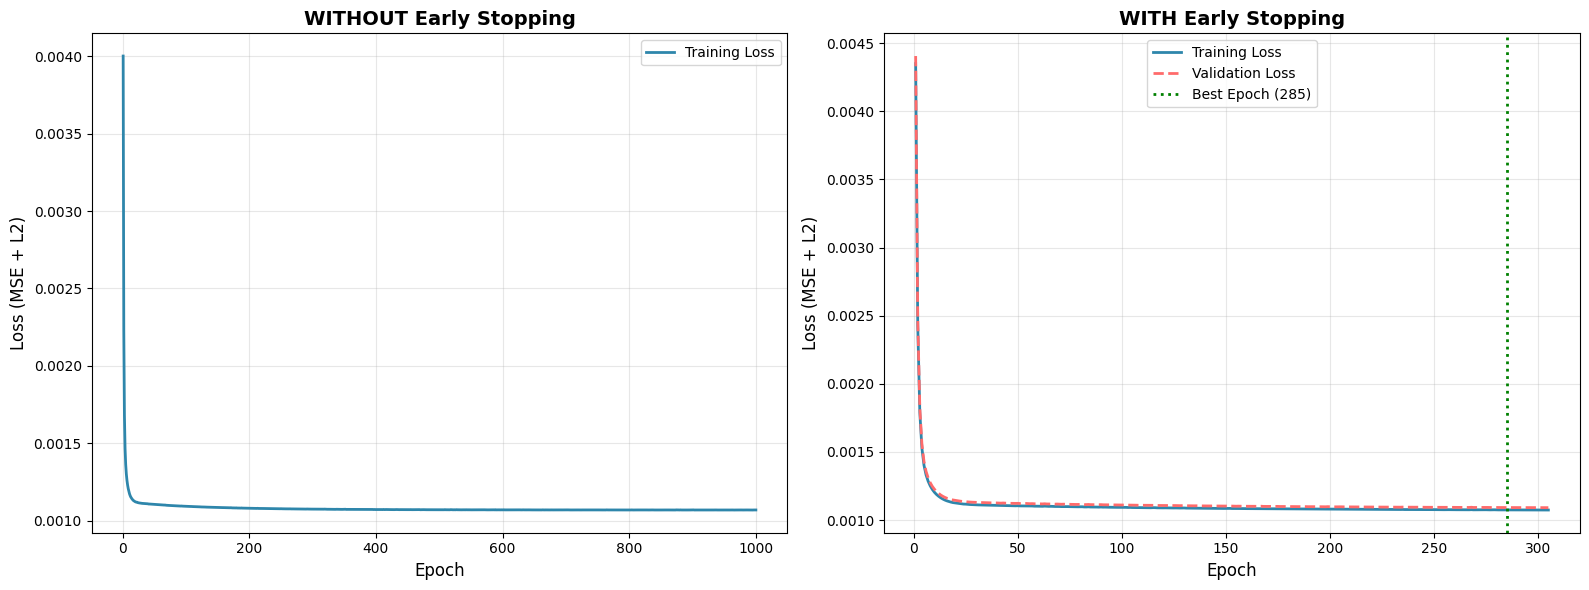


 Loss curves comparison plotted!


In [26]:
# Plot loss curves comparison
print("\n Comparing Loss Curves...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Without Early Stopping
epochs_no_es = range(1, len(sgd_scratch_model.loss_history_) + 1)
axes[0].plot(epochs_no_es, sgd_scratch_model.loss_history_, 
            linewidth=2, color='#2E86AB', label='Training Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE + L2)', fontsize=12)
axes[0].set_title('WITHOUT Early Stopping', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: With Early Stopping
epochs_with_es = range(1, len(sgd_with_es.loss_history_) + 1)
axes[1].plot(epochs_with_es, sgd_with_es.loss_history_, 
            linewidth=2, color='#2E86AB', label='Training Loss')
axes[1].plot(epochs_with_es, sgd_with_es.val_loss_history_, 
            linewidth=2, color='#FF6B6B', label='Validation Loss', linestyle='--')

if sgd_with_es.best_epoch_ is not None:
    axes[1].axvline(x=sgd_with_es.best_epoch_ + 1, color='green', 
                   linestyle=':', linewidth=2, label=f'Best Epoch ({sgd_with_es.best_epoch_ + 1})')

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (MSE + L2)', fontsize=12)
axes[1].set_title('WITH Early Stopping', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Loss curves comparison plotted!")

In [27]:
# Evaluate both models on test set
print("\n" + "="*80)
print(" PERFORMANCE COMPARISON")
print("="*80)

# Model 1: Without Early Stopping
y_pred_no_es = sgd_scratch_model.predict(X_test_scaled)
if use_log_target:
    y_pred_no_es = 10**y_pred_no_es - 1
    y_pred_no_es = np.maximum(y_pred_no_es, 0)

r2_no_es = r2_score(y_test, y_pred_no_es)
mae_no_es = mean_absolute_error(y_test, y_pred_no_es)
rmse_no_es = np.sqrt(mean_squared_error(y_test, y_pred_no_es))

# Model 2: With Early Stopping
y_pred_with_es = sgd_with_es.predict(X_test_scaled)
if use_log_target:
    y_pred_with_es = 10**y_pred_with_es - 1
    y_pred_with_es = np.maximum(y_pred_with_es, 0)

r2_with_es = r2_score(y_test, y_pred_with_es)
mae_with_es = mean_absolute_error(y_test, y_pred_with_es)
rmse_with_es = np.sqrt(mean_squared_error(y_test, y_pred_with_es))

# Print comparison table
print("\n Test Set Performance:")
print("\n" + "-"*80)
print(f"{'Metric':<25} {'Without ES':<20} {'With ES':<20} {'Difference'}")
print("-"*80)
print(f"{'R² Score':<25} {r2_no_es:<20.6f} {r2_with_es:<20.6f} {r2_with_es - r2_no_es:+.6f}")
print(f"{'MAE (km)':<25} {mae_no_es:<20.6f} {mae_with_es:<20.6f} {mae_with_es - mae_no_es:+.6f}")
print(f"{'RMSE (km)':<25} {rmse_no_es:<20.6f} {rmse_with_es:<20.6f} {rmse_with_es - rmse_no_es:+.6f}")
print("-"*80)

# Training efficiency
print("\n  Training Efficiency:")
print("-"*80)
print(f"{'Metric':<25} {'Without ES':<20} {'With ES':<20} {'Savings'}")
print("-"*80)
total_epochs_no_es = len(sgd_scratch_model.loss_history_)
total_epochs_with_es = len(sgd_with_es.loss_history_)
epoch_savings = total_epochs_no_es - total_epochs_with_es
savings_pct = (epoch_savings / total_epochs_no_es) * 100

print(f"{'Total Epochs':<25} {total_epochs_no_es:<20} {total_epochs_with_es:<20} {epoch_savings} ({savings_pct:.1f}%)")
print(f"{'Final Training Loss':<25} {sgd_scratch_model.loss_history_[-1]:<20.6f} {sgd_with_es.loss_history_[-1]:<20.6f}")
if sgd_with_es.stopped_epoch_ is not None:
    print(f"{'Best Epoch (ES)':<25} {'-':<20} {sgd_with_es.best_epoch_ + 1:<20}")
    print(f"{'Best Val Loss (ES)':<25} {'-':<20} {sgd_with_es.best_loss_:<20.6f}")
print("-"*80)

# Conclusion
print("\n Key Insights:")
if r2_with_es > r2_no_es:
    print(f"    Early Stopping IMPROVED R² by {(r2_with_es - r2_no_es):.6f}")
elif r2_with_es < r2_no_es:
    diff = r2_no_es - r2_with_es
    if diff < 0.001:
        print(f"    Early Stopping maintained similar R² (diff: {diff:.6f})")
    else:
        print(f"     Early Stopping decreased R² by {diff:.6f}")
else:
    print(f"    Both models achieved identical R²")

if epoch_savings > 0:
    print(f"     Early Stopping saved {epoch_savings} epochs ({savings_pct:.1f}% reduction)")
    print(f"    This means {savings_pct:.1f}% less computation time!")

if sgd_with_es.stopped_epoch_ is not None:
    print(f"    Model stopped early at epoch {sgd_with_es.stopped_epoch_ + 1}, preventing overfitting")
else:
    print(f"    Model trained for all {total_epochs_with_es} epochs (no early stopping triggered)")

print("\n" + "="*80)


 PERFORMANCE COMPARISON

 Test Set Performance:

--------------------------------------------------------------------------------
Metric                    Without ES           With ES              Difference
--------------------------------------------------------------------------------
R² Score                  0.927306             0.927661             +0.000354
MAE (km)                  0.222006             0.221722             -0.000284
RMSE (km)                 0.389269             0.388320             -0.000950
--------------------------------------------------------------------------------

  Training Efficiency:
--------------------------------------------------------------------------------
Metric                    Without ES           With ES              Savings
--------------------------------------------------------------------------------
Total Epochs              1000                 305                  695 (69.5%)
Final Training Loss       0.001069             0.001


 Visual Comparison of Predictions...


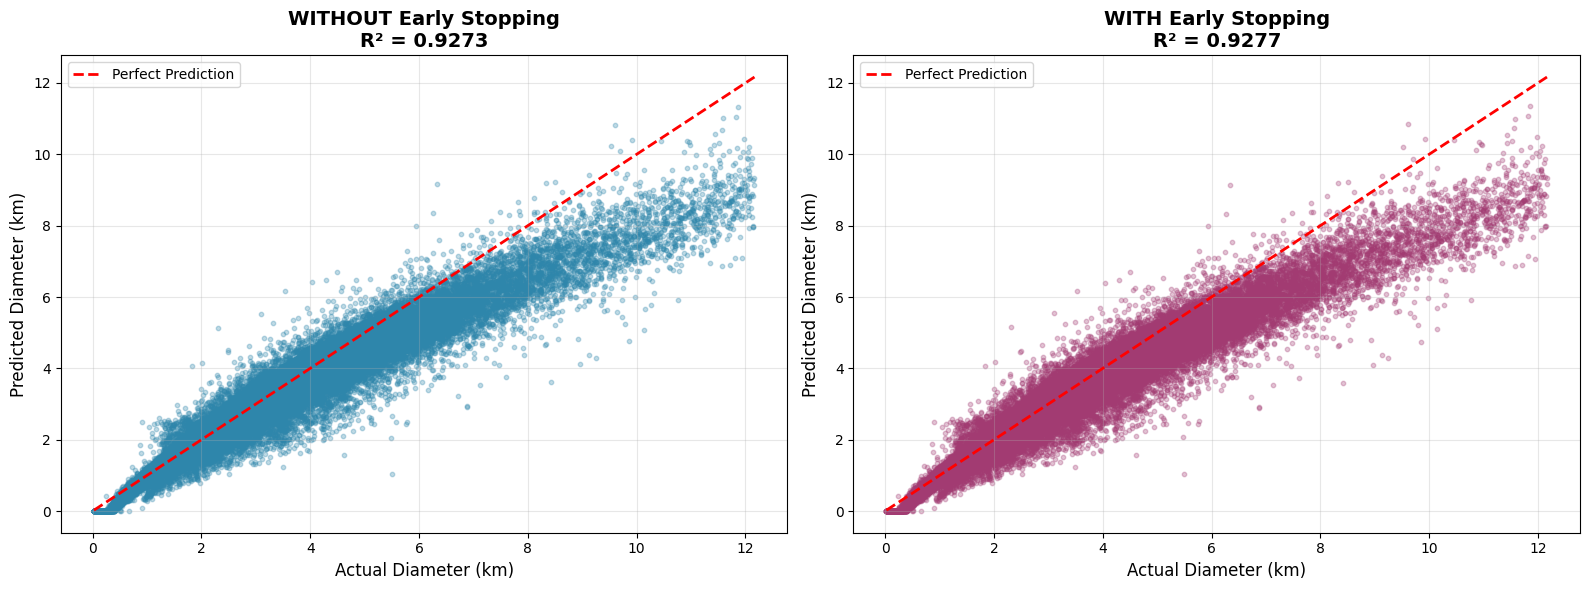

 Prediction comparison visualized!


In [28]:
# Visual comparison of predictions
print("\n Visual Comparison of Predictions...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Without Early Stopping
axes[0].scatter(y_test, y_pred_no_es, alpha=0.3, s=10, color='#2E86AB')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Diameter (km)', fontsize=12)
axes[0].set_ylabel('Predicted Diameter (km)', fontsize=12)
axes[0].set_title(f'WITHOUT Early Stopping\nR² = {r2_no_es:.4f}', 
                 fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: With Early Stopping
axes[1].scatter(y_test, y_pred_with_es, alpha=0.3, s=10, color='#A23B72')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Diameter (km)', fontsize=12)
axes[1].set_ylabel('Predicted Diameter (km)', fontsize=12)
axes[1].set_title(f'WITH Early Stopping\nR² = {r2_with_es:.4f}', 
                 fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Prediction comparison visualized!")

### Model Evaluation

Evaluate the model on the test set using standard metrics.

In [29]:
# Make predictions on test set
print("\n Making predictions on test set...")

if use_log_target:
    # Predict in log space
    y_pred_log = sgd_scratch_model.predict(X_test_scaled)
    
    # Transform back to original scale
    y_pred_scratch = 10 ** y_pred_log - 1
    y_test_original = y_test.values
else:
    y_pred_scratch = sgd_scratch_model.predict(X_test_scaled)
    y_test_original = y_test.values

print(" Predictions complete!")


 Making predictions on test set...
 Predictions complete!


In [30]:
# Calculate metrics
R2_Score = r2_score(y_test_original, y_pred_scratch)
MAE_Score = mean_absolute_error(y_test_original, y_pred_scratch)
MSE_Score = mean_squared_error(y_test_original, y_pred_scratch)
RMSE_Score = np.sqrt(MSE_Score)

print("\n" + "="*70)
print(" MODEL EVALUATION RESULTS")
print("="*70)
print(f"\n R² Score (Coefficient of Determination):")
print(f"   {R2_Score:.4f}")
if R2_Score >= 0.8:
    print("   ✅✅✅ Excellent! Target achieved (R² ≥ 0.8)")
elif R2_Score >= 0.6:
    print("   ✅✅ Very Good! (R² ≥ 0.6)")
elif R2_Score >= 0.4:
    print("   ✅ Good! (R² ≥ 0.4)")
else:
    print("   ⚠️ Needs improvement (R² < 0.4)")

print(f"\n  Mean Absolute Error (MAE):")
print(f"   {MAE_Score:.4f} km")
print(f"   (Average prediction error)")

print(f"\n  Mean Squared Error (MSE):")
print(f"   {MSE_Score:.4f} km²")

print(f"\n  Root Mean Squared Error (RMSE):")
print(f"   {RMSE_Score:.4f} km")
print(f"   (Standard deviation of errors)")

print("\n" + "="*70)


 MODEL EVALUATION RESULTS

 R² Score (Coefficient of Determination):
   0.9265
   ✅✅✅ Excellent! Target achieved (R² ≥ 0.8)

  Mean Absolute Error (MAE):
   0.2243 km
   (Average prediction error)

  Mean Squared Error (MSE):
   0.1532 km²

  Root Mean Squared Error (RMSE):
   0.3914 km
   (Standard deviation of errors)



In [31]:
# Display sample predictions
print("\n Sample Predictions (first 15 test samples):")
print("="*70)
print(f"{'Actual (km)':>12} | {'Predicted (km)':>15} | {'Error (km)':>12} | {'Error %':>10}")
print("="*70)

for i in range(min(15, len(y_test_original))):
    actual = y_test_original[i]
    predicted = y_pred_scratch[i]
    error = abs(actual - predicted)
    error_pct = (error / actual) * 100 if actual != 0 else 0
    
    print(f"{actual:12.4f} | {predicted:15.4f} | {error:12.4f} | {error_pct:9.2f}%")

print("="*70)


 Sample Predictions (first 15 test samples):
 Actual (km) |  Predicted (km) |   Error (km) |    Error %
      2.0260 |          2.2537 |       0.2277 |     11.24%
      2.7900 |          2.7464 |       0.0436 |      1.56%
      1.7860 |          1.9423 |       0.1563 |      8.75%
      2.6970 |          2.2576 |       0.4394 |     16.29%
      3.2520 |          3.1204 |       0.1316 |      4.05%
      2.6780 |          2.7032 |       0.0252 |      0.94%
      2.6950 |          2.7729 |       0.0779 |      2.89%
      1.5400 |          1.4665 |       0.0735 |      4.77%
      2.7570 |          2.8998 |       0.1428 |      5.18%
      1.4500 |          1.4231 |       0.0269 |      1.85%
      3.1060 |          2.9190 |       0.1870 |      6.02%
      2.6540 |          2.7507 |       0.0967 |      3.64%
      1.2600 |          1.4833 |       0.2233 |     17.72%
      2.3000 |          2.3654 |       0.0654 |      2.84%
      1.2060 |          1.1380 |       0.0680 |      5.64%


### Visualization: Actual vs Predicted

Visualize how well our predictions match the actual values.

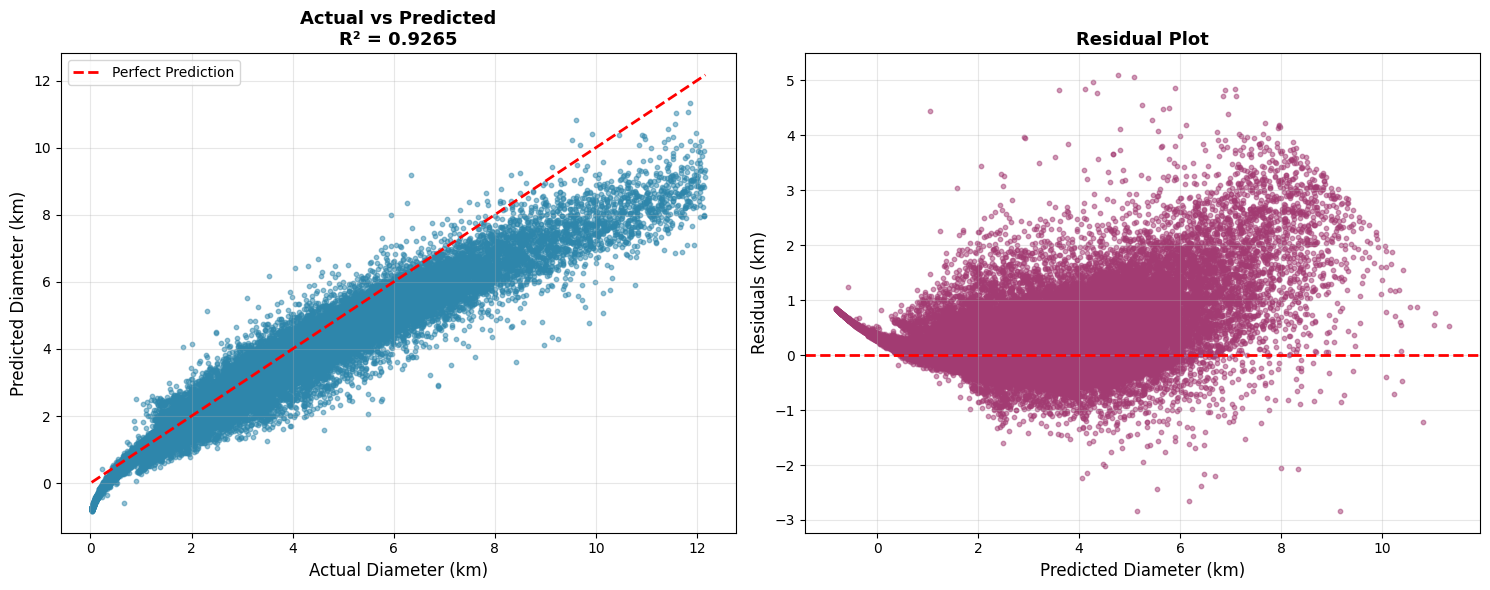

 Visualization complete!


In [32]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter plot of Actual vs Predicted
axes[0].scatter(y_test_original, y_pred_scratch, alpha=0.5, s=10, color='#2E86AB')
axes[0].plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Diameter (km)', fontsize=12)
axes[0].set_ylabel('Predicted Diameter (km)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted\nR² = {R2_Score:.4f}', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual plot
residuals = y_test_original - y_pred_scratch
axes[1].scatter(y_pred_scratch, residuals, alpha=0.5, s=10, color='#A23B72')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Diameter (km)', fontsize=12)
axes[1].set_ylabel('Residuals (km)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualization complete!")

### Feature Importance Analysis

Analyze which features are most important for prediction.

In [33]:
# Get feature importance (absolute values of weights)
print("\n Feature Importance Analysis:")
print("="*70)

feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Weight': sgd_scratch_model.weights_,
    'Abs_Weight': np.abs(sgd_scratch_model.weights_)
}).sort_values('Abs_Weight', ascending=False)

print("\n Top 10 Most Important Features:")
print("-" * 70)
for i, (idx, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    bar = '█' * int(row['Abs_Weight'] * 30)
    print(f"{i:2d}. {row['Feature']:15s}  Weight: {row['Weight']:+.4f}  {bar}")

print("\n" + "="*70)


 Feature Importance Analysis:

 Top 10 Most Important Features:
----------------------------------------------------------------------
 1. H                Weight: -0.1547  ████
 2. albedo           Weight: -0.0634  █
 3. q                Weight: +0.0565  █
 4. per_y            Weight: -0.0543  █
 5. n                Weight: +0.0342  █
 6. ad               Weight: +0.0339  █
 7. e                Weight: +0.0176  
 8. a                Weight: +0.0122  
 9. moid             Weight: +0.0083  
10. i                Weight: -0.0025  



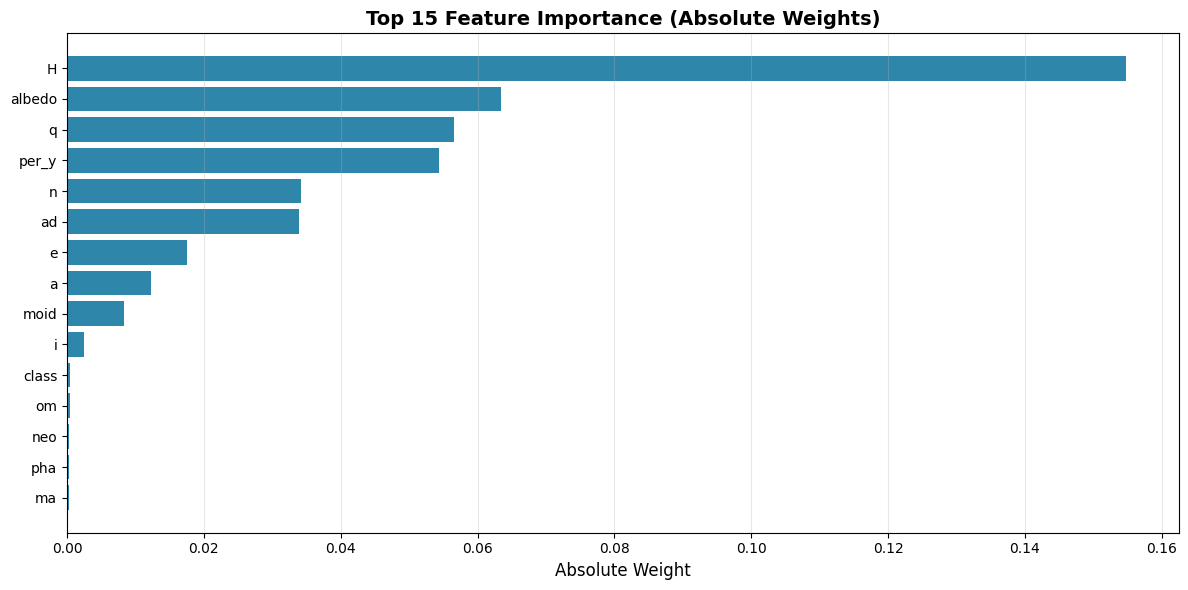

 Feature importance visualization complete!


In [34]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
top_n = 15
top_features = feature_importance.head(top_n)

plt.barh(range(len(top_features)), top_features['Abs_Weight'], color='#2E86AB')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Absolute Weight', fontsize=12)
plt.title(f'Top {top_n} Feature Importance (Absolute Weights)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(" Feature importance visualization complete!")

## Final Summary

Complete summary of the project results.

In [35]:
print("\n" + "="*80)
print(" FINAL PROJECT SUMMARY")
print("="*80)

print(f"\n  Dataset:")
print(f"   Total samples: {len(df):,}")
print(f"   Training samples: {len(X_train_scaled):,}")
print(f"   Test samples: {len(X_test_scaled):,}")
print(f"   Features: {X_train_scaled.shape[1]}")

print(f"\n  Model: Custom SGD Linear Regression")
print(f"   Algorithm: Stochastic Gradient Descent")
print(f"   Optimization: Momentum + L2 Regularization")
print(f"   Target Transform: {'Log10(diameter + 1)' if use_log_target else 'Original diameter'}")

print(f"\n  Hyperparameters:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Momentum: {MOMENTUM}")
print(f"   L2 Alpha: {ALPHA}")

print(f"\n  Performance Metrics:")
print(f"   R² Score:  {R2_Score:.4f}")
print(f"   MAE:       {MAE_Score:.4f} km")
print(f"   RMSE:      {RMSE_Score:.4f} km")

print(f"\n  Achievement:")
if R2_Score >= 0.8:
    print("   ✅✅✅ EXCELLENT! Target R² ≥ 0.8 achieved!")
    print("   You qualify for the bonus points! ")
elif R2_Score >= 0.6:
    print("   ✅✅ VERY GOOD! R² ≥ 0.6")
    print("   Strong performance, close to target!")
elif R2_Score >= 0.4:
    print("   ✅ GOOD! R² ≥ 0.4")
    print("   Solid baseline performance.")
else:
    print("   ⚠️ Room for improvement (R² < 0.4)")
    print("   Consider: more feature engineering, different model, or hyperparameter tuning.")

print(f"\n  Key Findings:")
print(f"   1. Most important feature: {feature_importance.iloc[0]['Feature']}")
print(f"   2. Log transformation {'improved' if use_log_target else 'not used for'} linearity")
print(f"   3. Final training loss: {sgd_scratch_model.loss_history_[-1]:.6f}")

print("\n" + "="*80)
print("  PROJECT COMPLETE!")
print("="*80)


 FINAL PROJECT SUMMARY

  Dataset:
   Total samples: 921,425
   Training samples: 722,404
   Test samples: 184,285
   Features: 16

  Model: Custom SGD Linear Regression
   Algorithm: Stochastic Gradient Descent
   Optimization: Momentum + L2 Regularization
   Target Transform: Log10(diameter + 1)

  Hyperparameters:
   Epochs: 1000
   Learning Rate: 0.001
   Batch Size: 512
   Momentum: 0.9
   L2 Alpha: 0.0001

  Performance Metrics:
   R² Score:  0.9265
   MAE:       0.2243 km
   RMSE:      0.3914 km

  Achievement:
   ✅✅✅ EXCELLENT! Target R² ≥ 0.8 achieved!
   You qualify for the bonus points! 

  Key Findings:
   1. Most important feature: H
   2. Log transformation improved linearity
   3. Final training loss: 0.001069

  PROJECT COMPLETE!
